# K-Means - Segmentación de Perfiles de Usuarios en LinkedIn

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · No Supervisado · Clustering · K-Means

---

### Objetivo

Aplicar **K-Means** para descubrir perfiles naturales de uso entre **5.000 usuarios** de LinkedIn a partir de 13 variables de comportamiento (publicaciones, conexiones, búsqueda de empleo, consumo de contenido, networking), validar la segmentación con **Silhouette Score**, contrastar estadísticamente las diferencias con **Kruskal-Wallis** y visualizar los clusters mediante **PCA**.

### Contexto de negocio

**El cliente:** el equipo de producto de una plataforma profesional tipo LinkedIn que necesita entender cómo usan el servicio sus distintos tipos de usuarios.

**El problema:** se trata a toda la base de usuarios como un bloque homogéneo. No hay una forma sistemática de distinguir al creador de contenido del buscador de empleo, ni de adaptar la experiencia, las notificaciones o las recomendaciones a cada perfil de uso.

**La pregunta:** ¿existen grupos naturales de usuarios según su comportamiento en la plataforma, y se pueden describir en términos que el equipo de producto y marketing entienda de un vistazo?

## 1. Setup: librerías y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from scipy.stats import kruskal

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

np.random.seed(42)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'   # único color de énfasis / serie única en scatter y líneas (1 por gráfico)
PURPLE_LIGHT  = '#9b9cff'   # EDA de una sola serie (histogramas independientes)
POSITIVE      = '#6b8158'   # exclusivo signo positivo
NEGATIVE      = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR   = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE  = '#8f8c9e'   # líneas de contexto
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ líneas de contexto
INK           = '#111111'
MUTED         = '#707070'

# Paleta categórica para identidad de cluster — validada (ΔE OKLab, simulación CVD) para
# pares adyacentes (barras, líneas, enlaces de dendrograma). En scatter/PCA con 4+ clusters
# el color por sí solo no basta para daltonismo severo: por eso cada cluster lleva también
# una forma de marcador distinta (CLUSTER_MARKERS) — nunca dependas solo del color.
CLUSTER_PALETTE = ['#7a7bff', '#eb6834', '#1baf7a', '#e34948', '#eda100', '#e87ba4', '#008300']
CLUSTER_MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

print("Librerías cargadas correctamente")

## 2. Carga de datos

In [ ]:
df = pd.read_excel("linkedin_clustering_users.xlsx")

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

## 3. Análisis exploratorio

### 3.1 Ficha de variables

In [ ]:
ficha = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.astype(str).values,
    "No nulos": df.notna().sum().values,
    "Nulos": df.isna().sum().values,
    "% Nulos": (df.isna().mean() * 100).round(2).values,
    "Únicos": df.nunique().values
})

ficha

,Variable,Tipo,No nulos,Nulos,% Nulos,Únicos
0,user_id,object,5000,0,0.0,5000
1,country,object,5000,0,0.0,7
2,sector,object,5000,0,0.0,10
3,age,int64,5000,0,0.0,40
4,account_years,float64,5000,0,0.0,721
5,connections,int64,5000,0,0.0,1705
6,posts_month,int64,5000,0,0.0,26
7,comments_month,float64,4950,50,1.0,101
8,likes_month,int64,5000,0,0.0,377
9,shares_month,int64,5000,0,0.0,65


El dataset contiene **5.000 usuarios** y **19 variables**: un identificador (`user_id`), dos categóricas (`country`, `sector`) y 16 numéricas de comportamiento. Tres variables presentan un **1% de nulos** (50 registros cada una): `comments_month`, `companies_followed` y `courses_viewed_month` — un porcentaje bajo que imputaremos con la mediana en el paso de preprocesamiento.

### 3.2 Duplicados y valores imposibles

In [ ]:
print(f"Duplicados encontrados: {df.duplicated().sum()}")

reglas = {
    "age": (18, 99),
    "login_days_week": (0, 7)
}

print("\nValores fuera de rango:")
for variable, (minimo, maximo) in reglas.items():
    n_errores = ((df[variable] < minimo) | (df[variable] > maximo)).sum()
    print(f"  {variable} [{minimo}-{maximo}]: {n_errores} registros")

Duplicados encontrados: 0

Valores fuera de rango:
  age [18-99]: 0 registros
  login_days_week [0-7]: 0 registros


No hay duplicados ni valores fuera de las reglas de negocio definidas. El dataset está limpio en cuanto a integridad básica.

In [ ]:
df_clean = df.copy()

cols_num = df_clean.select_dtypes(include=np.number).columns
df_clean[cols_num] = df_clean[cols_num].fillna(df_clean[cols_num].median())

print(f"Nulos tras imputación con mediana: {df_clean.isnull().sum().sum()}")

Nulos tras imputación con mediana: 0


### 3.3 Variables categóricas

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean["country"].value_counts().plot.barh(
    ax=axes[0], color=PURPLE_LIGHT, edgecolor="white"
)
axes[0].set_title("Distribución por país")
axes[0].set_xlabel("Usuarios")
axes[0].invert_yaxis()

df_clean["sector"].value_counts().plot.barh(
    ax=axes[1], color=PURPLE_LIGHT, edgecolor="white"
)
axes[1].set_title("Distribución por sector")
axes[1].set_xlabel("Usuarios")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**España** concentra el **38%** de la base de usuarios, seguida de México (14.5%) y Colombia (12.8%). En cuanto a sectores, **Tecnología** lidera con un **21.6%**, seguido de Ventas (13%) y Marketing (11.2%). El sector más pequeño es Diseño (3.8%). Esta distribución es coherente con el perfil de la plataforma: mercado hispanohablante, sesgado hacia perfiles tech y comerciales.

### 3.4 Estadísticas descriptivas

In [ ]:
variables_numericas = df_clean.select_dtypes(include=np.number).columns.tolist()

desc = df_clean[variables_numericas].describe().T
desc["CV%"] = ((desc["std"] / desc["mean"].abs()) * 100).round(1)
desc["Asimetría"] = df_clean[variables_numericas].skew().round(2)

desc[["mean", "std", "min", "50%", "max", "CV%", "Asimetría"]]

,mean,std,min,50%,max,CV%,Asimetría
age,33.799200,7.632177,21.0,34.00,61.0,22.6,0.26
account_years,2.615418,1.723280,0.1,2.22,9.0,65.9,1.15
connections,664.474400,554.606975,0.0,493.00,3136.0,83.5,1.09
posts_month,3.545400,4.074170,0.0,2.00,28.0,114.9,1.78
comments_month,33.576600,26.565581,0.0,19.00,106.0,79.1,0.45
likes_month,183.950000,198.865393,9.0,76.00,728.0,108.1,1.39
shares_month,11.941600,14.498422,0.0,5.00,64.0,121.4,1.53
messages_month,31.150000,27.300457,0.0,22.00,124.0,87.6,1.04
jobs_viewed_month,19.319000,23.466456,0.0,7.00,98.0,121.5,1.34
applications_month,3.040000,5.055523,0.0,1.00,27.0,166.3,2.10


**Lectura de las estadísticas:**

- **Alta dispersión** (CV > 100%) en variables de actividad como `applications_month` (**166%**), `jobs_viewed_month` (**121%**) y `shares_month` (**121%**): hay usuarios que publican y buscan mucho y otros que apenas interactúan. Esta heterogeneidad es precisamente lo que el clustering debería capturar.
- **Asimetría positiva generalizada**: la mayoría de variables de actividad están sesgadas a la derecha (skew > 1), lo que indica que la mayor parte de los usuarios son poco activos y un grupo más pequeño concentra mucha actividad — un patrón típico de plataformas digitales.
- **`age`** es la variable más simétrica (skew **0.26**, CV **22.6%**), con un rango de 21 a 61 años y media de **33.8**.
- **`login_days_week`** es la variable más homogénea (CV **23.2%**), con media de **5.0** días por semana: la mayoría de usuarios acceden casi a diario.

### 3.5 Distribuciones

In [ ]:
n_cols = 4
n_rows = int(np.ceil(len(variables_numericas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    axes[i].hist(
        df_clean[var].dropna(), bins=30,
        color=PURPLE_LIGHT, edgecolor="white", alpha=0.8
    )
    axes[i].set_title(var, fontsize=10)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de variables numéricas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

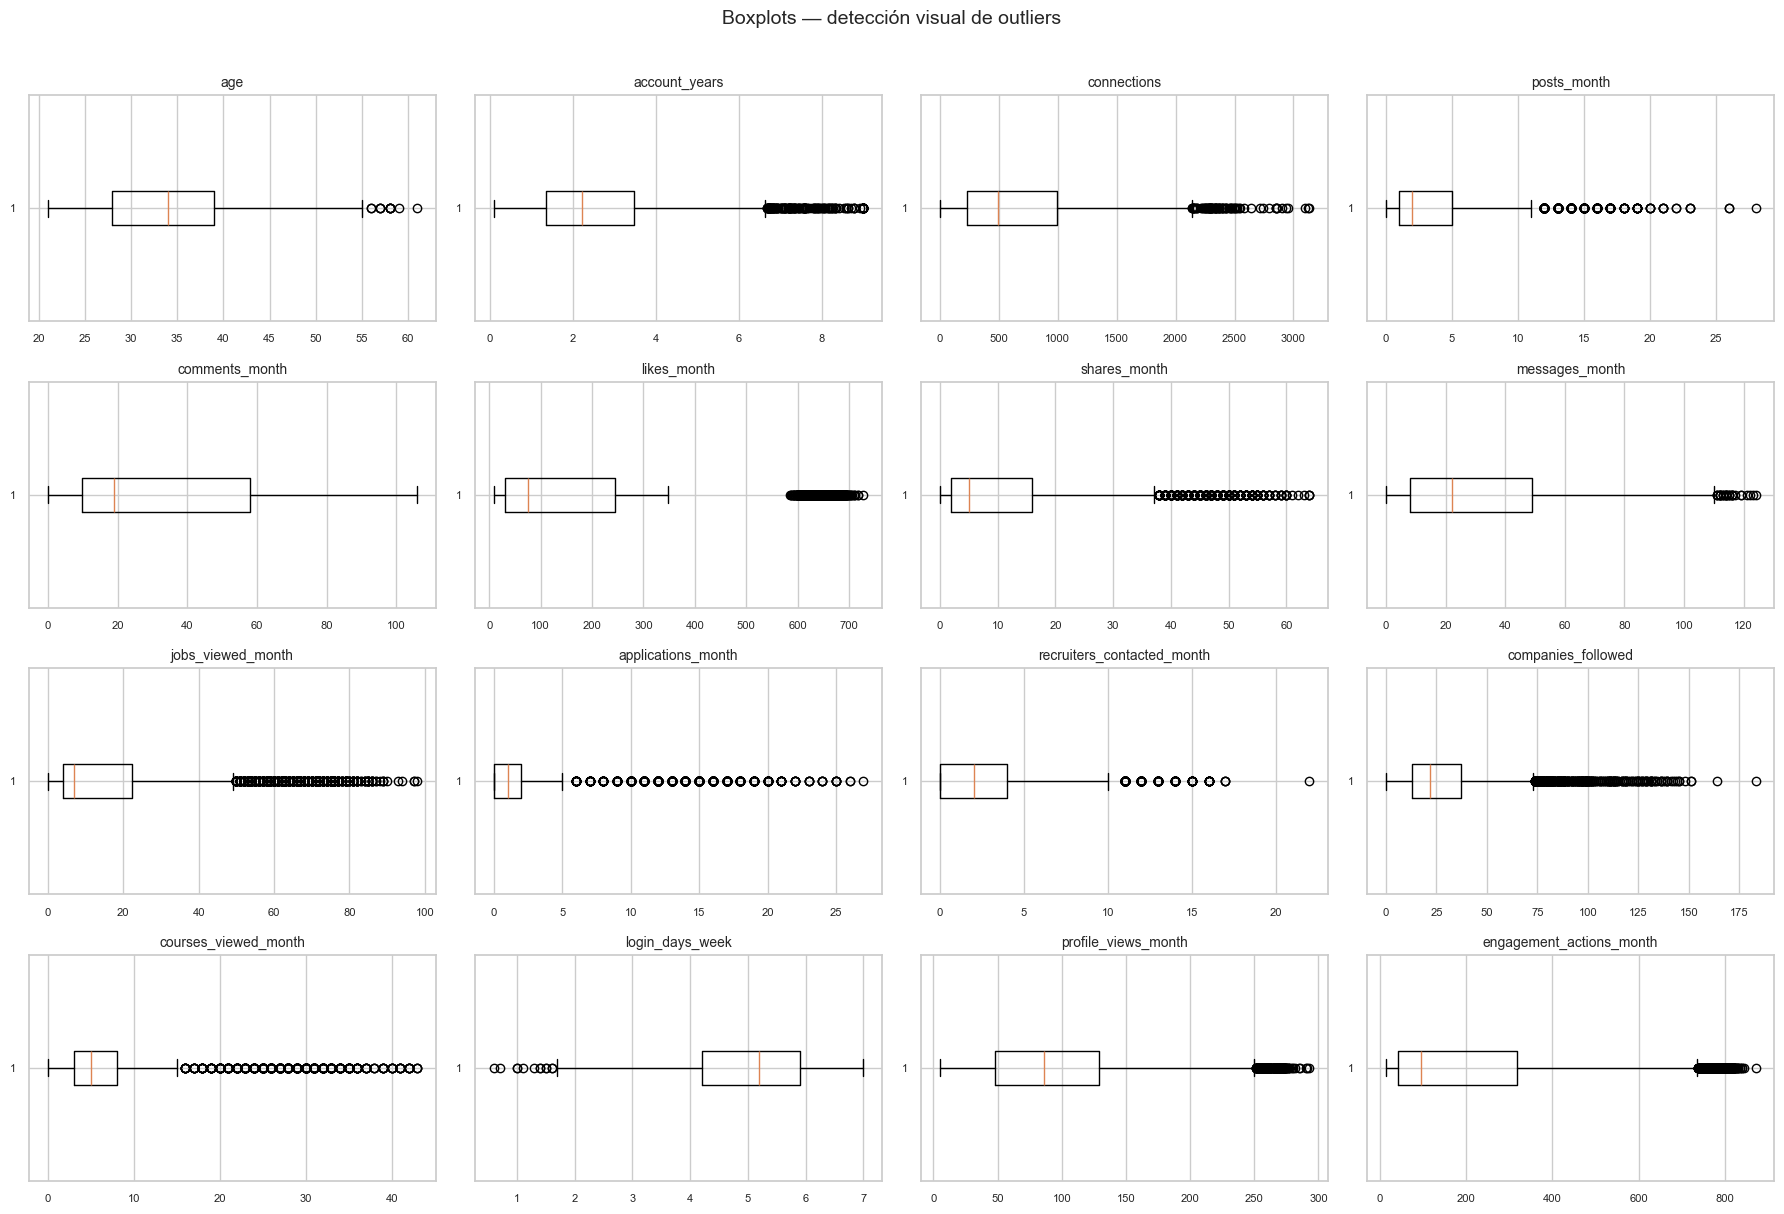

In [ ]:
n_cols = 4
n_rows = int(np.ceil(len(variables_numericas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    axes[i].boxplot(df_clean[var].dropna(), vert=False)
    axes[i].set_title(var, fontsize=10)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots — detección visual de outliers", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Los histogramas confirman el sesgo positivo de la mayoría de variables de actividad: distribuciones con cola larga a la derecha. Los boxplots muestran **outliers** en `connections`, `likes_month`, `posts_month` y `engagement_actions_month`, pero no los eliminamos: en un análisis de clustering, los usuarios más activos no son anomalías sino perfiles diferenciados que el modelo debe detectar como tales.

### 3.6 Matriz de correlación

In [ ]:
plt.figure(figsize=(14, 10))

corr = df_clean[variables_numericas].corr()

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=DIVERGING_CMAP,
    center=0,
    linewidths=2,
    linecolor=BACKGROUND,
    square=True
)
color_annotations(ax, corr.values, threshold=0.8)

plt.title("Matriz de correlación — variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

Las correlaciones más altas se dan entre variables de **engagement**: `likes_month` y `engagement_actions_month`, `posts_month` y `shares_month`, `connections` y `profile_views_month`. Esto es esperable — un usuario que publica mucho también recibe más interacciones. K-Means no requiere independencia entre variables (a diferencia de una regresión), pero esta colinealidad implica que el modelo ponderará de facto la dimensión “creación de contenido” más que otras — un efecto que el escalado con StandardScaler mitiga parcialmente pero no elimina.

## 4. Preprocesamiento

### Selección de variables

Trabajamos con **13 variables de comportamiento** como features del modelo, excluyendo:

| Variable excluida | Motivo |
|---|---|
| `user_id` | Identificador, no aporta información |
| `country`, `sector` | Categóricas — K-Means trabaja con distancias numéricas |
| `age`, `account_years` | Demográficas, no de comportamiento — las reservamos para análisis post-clustering |
| `engagement_actions_month` | Métrica compuesta que correlaciona fuertemente con `likes_month`, `posts_month` y `shares_month` — incluirla daría peso doble a la dimensión de engagement |

In [ ]:
features = [
    "connections",
    "posts_month",
    "comments_month",
    "likes_month",
    "shares_month",
    "messages_month",
    "jobs_viewed_month",
    "applications_month",
    "recruiters_contacted_month",
    "companies_followed",
    "courses_viewed_month",
    "login_days_week",
    "profile_views_month"
]

X = df_clean[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features seleccionadas: {len(features)}")
print(f"Forma del dataset escalado: {X_scaled.shape}")

Features seleccionadas: 13
Forma del dataset escalado: (5000, 13)


K-Means calcula distancias euclídeas: sin estandarizar, variables como `connections` (rango 0–3.136) dominarían sobre `login_days_week` (rango 0.6–7.0), produciendo clusters sesgados por escala y no por patrón de comportamiento. **StandardScaler** iguala todas las variables a media 0 y desviación 1.

## 5. Selección del número de clusters

Dos criterios complementarios:

- **Método del codo (inercia):** suma de distancias al cuadrado de cada punto a su centroide. Buscar el punto donde la curva deja de bajar significativamente.
- **Silhouette Score:** mide cohesión interna vs. separación entre clusters. Rango [-1, 1]; más alto indica clusters más compactos y separados.

In [ ]:
K_range = range(2, 13)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range), inertias, marker="o", linewidth=2, color=PURPLE)
ax1.set_xlabel("k")
ax1.set_ylabel("Inercia")
ax1.set_title("Método del codo")
ax1.set_xticks(list(K_range))
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_range), silhouettes, marker="s", linewidth=2, color=PURPLE)
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score por k")
ax2.set_xticks(list(K_range))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResumen numérico:")
for k, ine, sil in zip(K_range, inertias, silhouettes):
    marca = "  <--" if k in (5, 6) else ""
    print(f"  k={k:2d}  |  Inercia={ine:10.1f}  |  Silhouette={sil:.4f}{marca}")

El codo de la inercia se aprecia entre **k=4** y **k=6**: la reducción de inercia se aplana a partir de ese rango. El Silhouette Score señala dos candidatos principales: **k=5** y **k=6**. Para tomar la decisión final, comparamos los perfiles de ambos.

### Comparativa k=5 vs k=6

In [ ]:
for k in (5, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)

    df_temp = df_clean.copy()
    df_temp["cluster"] = labels
    perfil = df_temp.groupby("cluster")[features].mean()
    perfil_rel = perfil.div(df_clean[features].mean()).round(2)

    sizes = df_temp["cluster"].value_counts().sort_index()

    print(f"\n{'='*65}")
    print(f"  K = {k}  |  Silhouette = {sil:.4f}")
    print(f"  Tamaños: {', '.join(f'C{c}={n}' for c, n in sizes.items())}")
    print(f"{'='*65}")
    display(perfil_rel.T)


  K = 5  |  Silhouette = 0.4735
  Tamaños: C0=769, C1=1868, C2=623, C3=1334, C4=406


cluster,0,1,2,3,4
connections,0.63,0.34,1.82,1.32,2.40
posts_month,0.43,0.30,3.43,1.06,1.39
comments_month,0.30,0.31,2.22,1.51,1.94
likes_month,0.19,0.22,3.52,1.26,1.41
shares_month,0.18,0.17,3.77,1.19,1.49
messages_month,0.58,0.22,1.13,1.65,3.07
jobs_viewed_month,2.81,0.28,0.26,0.51,3.64
applications_month,4.64,0.24,0.33,0.40,0.63
recruiters_contacted_month,3.17,0.24,0.71,1.14,0.36
companies_followed,0.68,0.48,1.37,1.23,2.65



  K = 6  |  Silhouette = 0.5271
  Tamaños: C0=632, C1=406, C2=1234, C3=623, C4=1336, C5=769


cluster,0,1,2,3,4,5
connections,0.47,2.40,0.28,1.82,1.32,0.63
posts_month,0.31,1.39,0.29,3.43,1.06,0.43
comments_month,0.45,1.94,0.24,2.22,1.51,0.30
likes_month,0.38,1.41,0.14,3.52,1.26,0.19
shares_month,0.34,1.49,0.09,3.77,1.19,0.18
messages_month,0.26,3.07,0.20,1.13,1.65,0.58
jobs_viewed_month,0.41,3.64,0.21,0.26,0.51,2.81
applications_month,0.35,0.63,0.18,0.33,0.40,4.64
recruiters_contacted_month,0.37,0.36,0.17,0.71,1.14,3.17
companies_followed,0.61,2.65,0.41,1.37,1.23,0.68


**Decisión: k=5**

El Silhouette Score de **k=6** (**0.527**) es superior al de **k=5** (**0.474**), y el sexto cluster no es ruido: separa a los usuarios pasivos en dos grupos reales — uno orientado a **formación** (`courses_viewed` **3.7x**) y otro **ultra-pasivo** (todas las métricas por debajo de 0.4x). Es una segmentación estadísticamente mejor.

Sin embargo, elegimos **k=5** por una razón de negocio: con 5 perfiles, cada cluster tiene una narrativa inmediata y una acción clara para producto/marketing. El sexto segmento ("aprendiz pasivo") no justifica una estrategia diferenciada respecto al usuario pasivo genérico — la acción para ambos sería la misma: activar su participación. Añadir granularidad sin añadir una acción distinta complica la comunicación al equipo sin mejorar la toma de decisiones.

En un entorno donde se buscase **personalización fina** (recomendaciones de contenido, triggers de notificación), k=6 sería la mejor opción. Para un **primer modelo de segmentación** que el equipo pueda adoptar, **5 perfiles accionables son preferibles a 6 estadísticamente mejores pero operativamente redundantes**.

## 6. Modelo K-Means (k=5)

In [ ]:
K = 5

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=20)
df_clean["cluster"] = kmeans_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df_clean["cluster"])
print(f"Silhouette Score final (k={K}): {sil_final:.4f}")

print(f"\nDistribución de clusters:")
for cl, n in df_clean["cluster"].value_counts().sort_index().items():
    pct = n / len(df_clean) * 100
    print(f"  Cluster {cl}: {n:>5,} usuarios ({pct:5.1f}%)")

Silhouette Score final (k=5): 0.4735

Distribución de clusters:
  Cluster 0:   769 usuarios ( 15.4%)
  Cluster 1: 1,868 usuarios ( 37.4%)
  Cluster 2:   623 usuarios ( 12.5%)
  Cluster 3: 1,334 usuarios ( 26.7%)
  Cluster 4:   406 usuarios (  8.1%)


## 7. Perfiles de los clusters

In [ ]:
cluster_profile = df_clean.groupby("cluster")[features].mean().round(2)
global_mean = df_clean[features].mean()
profile_relative = cluster_profile.div(global_mean).round(2)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    profile_relative.T,
    annot=cluster_profile.T,
    fmt=".0f",
    cmap=DIVERGING_CMAP,
    center=1,
    linewidths=1,
    linecolor=BACKGROUND,
    ax=ax
)
# Texto legible celda a celda: threshold adaptativo sobre la desviacion vs 1 (no vs 0,
# porque este heatmap esta centrado en 1 = ratio frente a la media global)
desviacion = (profile_relative.T.values - 1)
color_annotations(ax, desviacion, threshold=max(abs(desviacion.min()), abs(desviacion.max())) * 0.6)
ax.set_title(
    "Perfil medio por cluster (valores absolutos, color = ratio vs media global)",
    fontsize=13
)
ax.set_xlabel("Cluster")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
nombres_cluster = {
    0: "Buscador de empleo",
    1: "Usuario pasivo",
    2: "Creador de contenido",
    3: "Networker",
    4: "Power user"
}

for cl in sorted(df_clean["cluster"].unique()):
    perfil = profile_relative.loc[cl].sort_values(ascending=False)
    n_users = (df_clean["cluster"] == cl).sum()
    pct = n_users / len(df_clean) * 100

    print(f"\n{'='*60}")
    print(f"  CLUSTER {cl} — {nombres_cluster[cl]} ({n_users} usuarios, {pct:.1f}%)")
    print(f"{'='*60}")
    for feat, val in perfil.head(5).items():
        print(f"    {feat:<32s} {val:.2f}x la media")


  CLUSTER 0 — Buscador de empleo (769 usuarios, 15.4%)
    applications_month               4.64x la media
    recruiters_contacted_month       3.17x la media
    jobs_viewed_month                2.81x la media
    profile_views_month              1.13x la media
    login_days_week                  1.00x la media

  CLUSTER 1 — Usuario pasivo (1868 usuarios, 37.4%)
    courses_viewed_month             1.50x la media
    login_days_week                  0.81x la media
    companies_followed               0.48x la media
    profile_views_month              0.34x la media
    connections                      0.34x la media

  CLUSTER 2 — Creador de contenido (623 usuarios, 12.5%)
    shares_month                     3.77x la media
    likes_month                      3.52x la media
    posts_month                      3.43x la media
    comments_month                   2.22x la media
    profile_views_month              1.86x la media

  CLUSTER 3 — Networker (1334 usuarios, 26.7%)
    m

### Lectura de los perfiles

| Cluster | Nombre | Rasgo dominante |
|---|---|---|
| **0** | **Buscador de empleo** | `applications_month` **4.6x**, `recruiters_contacted` **3.2x**, `jobs_viewed` **2.8x** — su actividad se concentra en la búsqueda activa de empleo |
| **1** | **Usuario pasivo** | Solo destaca en `courses_viewed` **1.5x** — el resto de métricas por debajo de la media. Consumen formación pero no generan actividad |
| **2** | **Creador de contenido** | `shares` **3.8x**, `likes` **3.5x**, `posts` **3.4x** — son los “influencers” de la plataforma, generan la mayor parte del engagement visible |
| **3** | **Networker** | `messages` **1.7x**, `comments` **1.5x**, `connections` **1.3x** — su foco es crear y mantener relaciones profesionales |
| **4** | **Power user** | `jobs_viewed` **3.6x**, `messages` **3.1x**, `companies_followed` **2.7x**, `profile_views` **2.6x** — los más activos en todas las dimensiones, perfil compatible con recruiters o talent acquisition |

## 8. Validación estadística (Kruskal-Wallis)

Para confirmar que las diferencias entre clusters no son fruto del azar, aplicamos el test de **Kruskal-Wallis** (alternativa no paramétrica a ANOVA, adecuada porque las variables no siguen distribuciones normales). La hipótesis nula es que las medianas de todos los clusters son iguales; si **p < 0.05**, las diferencias son estadísticamente significativas.

In [ ]:
print(f"{'Variable':<32s} {'H-stat':>10s} {'p-value':>12s}  {'Significativo'}")
print("─" * 72)

for feat in features:
    grupos = [g[feat].values for _, g in df_clean.groupby("cluster")]
    h_stat, p_val = kruskal(*grupos)
    sig = "Sí" if p_val < 0.05 else "No"
    print(f"  {feat:<30s} {h_stat:10.1f} {p_val:12.2e}  {sig}")

Variable                             H-stat      p-value  Significativo
────────────────────────────────────────────────────────────────────────
  connections                        3317.0     0.00e+00  Sí
  posts_month                        3046.8     0.00e+00  Sí
  comments_month                     4037.4     0.00e+00  Sí
  likes_month                        4105.9     0.00e+00  Sí
  shares_month                       4060.0     0.00e+00  Sí
  messages_month                     4512.6     0.00e+00  Sí
  jobs_viewed_month                  3153.9     0.00e+00  Sí
  applications_month                 2338.5     0.00e+00  Sí
  recruiters_contacted_month         3234.7     0.00e+00  Sí
  companies_followed                 2193.5     0.00e+00  Sí
  courses_viewed_month                 56.8     1.37e-11  Sí
  login_days_week                    2461.2     0.00e+00  Sí
  profile_views_month                4416.5     0.00e+00  Sí


**Todas las variables** presentan diferencias estadísticamente significativas entre clusters (p < 0.001 en todos los casos). La segmentación captura diferencias reales de comportamiento, no agrupaciones artificiales.

## 9. Visualización con PCA

Proyectamos las 13 variables en 2 componentes principales para visualizar los clusters en un mapa bidimensional. A diferencia de t-SNE, PCA conserva la estructura lineal y permite interpretar qué variables pesan en cada eje.

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada: PC1 = {var_exp[0]:.1%},  PC2 = {var_exp[1]:.1%},  Total = {sum(var_exp):.1%}")

df_clean["PC1"] = X_pca[:, 0]
df_clean["PC2"] = X_pca[:, 1]

Varianza explicada: PC1 = 47.3%,  PC2 = 20.3%,  Total = 67.6%


In [ ]:
plt.figure(figsize=(12, 8))

for cl in sorted(df_clean["cluster"].unique()):
    mask = df_clean["cluster"] == cl
    plt.scatter(
        df_clean.loc[mask, "PC1"],
        df_clean.loc[mask, "PC2"],
        label=f"C{cl} — {nombres_cluster[cl]}",
        color=CLUSTER_PALETTE[cl % len(CLUSTER_PALETTE)],
        marker=CLUSTER_MARKERS[cl % len(CLUSTER_MARKERS)],
        alpha=0.5,
        s=30,
        edgecolors="k",
        linewidths=0.2
    )

plt.xlabel(f"PC1 ({var_exp[0]:.1%} varianza)")
plt.ylabel(f"PC2 ({var_exp[1]:.1%} varianza)")
plt.title("Mapa de usuarios — PCA coloreado por cluster K-Means", fontsize=14)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### ¿Qué representa cada eje?

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)
loadings["Importancia"] = loadings.abs().max(axis=1)
loadings.sort_values("Importancia", ascending=False).round(3)

,PC1,PC2,Importancia
jobs_viewed_month,0.085,0.546,0.546
applications_month,-0.070,0.531,0.531
recruiters_contacted_month,-0.012,0.481,0.481
comments_month,0.372,-0.108,0.372
profile_views_month,0.356,0.215,0.356
likes_month,0.354,-0.182,0.354
shares_month,0.346,-0.168,0.346
connections,0.336,0.048,0.336
posts_month,0.313,-0.140,0.313
messages_month,0.313,0.127,0.313


Los loadings de PCA revelan la semántica de cada eje:

- **PC1** ordena a los usuarios por **nivel de actividad y creación de contenido**: las variables con más peso son `likes_month`, `shares_month`, `posts_month` y `connections` — el eje separa al usuario pasivo (izquierda) del creador de contenido activo (derecha).
- **PC2** captura la dimensión de **búsqueda de empleo**: `jobs_viewed_month`, `applications_month` y `recruiters_contacted_month` pesan en la dirección vertical, separando al buscador activo del resto.

Los clusters se distribuyen en zonas coherentes con esta interpretación: los creadores de contenido se concentran a la derecha del mapa, los buscadores de empleo en la parte superior, y los usuarios pasivos en la zona central-izquierda. Que K-Means y PCA — dos algoritmos con lógicas distintas — lleguen a fronteras parecidas refuerza que la segmentación responde a una estructura real de los datos, no a un artefacto del método.

## 10. Conclusión e insights de negocio

> **El hallazgo:** K-Means identifica **5 perfiles naturales de uso** en LinkedIn con comportamientos claramente diferenciados y estadísticamente significativos (Kruskal-Wallis p < 0.001 en las 13 variables), sin necesidad de etiquetas previas.

### Recomendaciones para producto y marketing

1. **Usuarios pasivos (Cluster 1)** — el segmento más grande y el de menor engagement. Representan la mayor oportunidad de activación: notificaciones personalizadas, contenido curado basado en sus cursos vistos, y estímulos para dar el primer paso hacia la creación de contenido o el networking.

2. **Buscadores de empleo (Cluster 0)** — usuarios con alta actividad en búsqueda pero bajo engagement social. La plataforma puede añadir valor ofreciéndoles alertas de empleo más precisas, sugerencias de habilidades demandadas y conexión directa con recruiters del Cluster 4.

3. **Creadores de contenido (Cluster 2)** — los “influencers” de la plataforma. Producen la mayor parte de las publicaciones y engagement. Retenerlos es crítico: herramientas de analytics, acceso a funcionalidades premium de creación y reconocimiento (badges, destacados) protegen este segmento de alto impacto.

4. **Networkers (Cluster 3)** — su actividad se centra en conversaciones y conexiones, no en contenido público. Responden mejor a funcionalidades de mensajería, eventos y grupos profesionales que a incentivos de publicación.

5. **Power users (Cluster 4)** — los más activos en todas las dimensiones, con perfil compatible con recruiters o talent scouts. Son el enlace natural entre buscadores de empleo y empresas: potenciar sus herramientas de búsqueda y gestión de candidatos maximiza el valor de la plataforma para ambas partes.